# Olist Brazilian E-Commerce — Data Analysis

## Project Overview
End-to-end analysis of the Olist Brazilian e-commerce dataset using SQL, Excel, Power BI, 
and Python. This notebook covers exploratory data analysis, statistical testing, NLP on 
customer reviews, and predictive modeling.

## Dataset
- **Source:** Kaggle — olistbr/brazilian-ecommerce
- **Size:** 99,441 orders, 9 relational tables
- **Period:** October 2016 — August 2018

## Tools Used
- **SQL (PostgreSQL):** Database setup, 10 analytical queries
- **Excel:** Power Query, XLOOKUP, SUMIFS, pivot tables
- **Power BI:** 5-page interactive dashboard with DAX measures
- **Python:** EDA, statistical testing, NLP, machine learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

In [2]:
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
df_orders = pd.read_csv('../data/olist_orders_dataset.csv', parse_dates=['order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'])
df_order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
df_order_payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
df_order_reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv', parse_dates=['review_creation_date',
       'review_answer_timestamp'])
df_sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
df_customers = pd.read_csv('../data/olist_customers_dataset.csv')

In [4]:
dataframes = {
    'orders': df_orders,
    'order_items': df_order_items,
    'order_payments': df_order_payments,
    'order_reviews': df_order_reviews,
    'sellers': df_sellers,
    'customers': df_customers
}

for name, df in dataframes.items():
    print(f'{name}: {df.shape[0]:,} rows, {df.shape[1]} columns')

orders: 99,441 rows, 8 columns
order_items: 112,650 rows, 7 columns
order_payments: 103,886 rows, 5 columns
order_reviews: 99,224 rows, 7 columns
sellers: 3,095 rows, 4 columns
customers: 99,441 rows, 5 columns


## Exploratory Data Analysis

In [5]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [6]:
df_orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

We see from this that there are missing values for `order_approved_at`,`order_delivered_carrier_date`, and `order_delivered_customer_date`, which means that this dataset contains orders that have not been delivered yet. 

In [7]:
df_orders.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581,2017-12-31 18:35:24.098800,2018-01-04 21:49:48.138278,2018-01-14 12:09:19.035542,2018-01-24 03:08:37.730111
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.250000,2017-09-25 22:07:22.250000,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.250000,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


## Master Dataframe

### Aggregating Order Items

In [8]:
df_order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [9]:
df_order_items_agg = df_order_items.groupby('order_id').agg({'order_item_id': 'count', 'price': 'sum', 'freight_value': 'sum'}).rename(columns={
    'order_item_id': 'item_count'
}).reset_index()

In [10]:
df_order_items_agg.shape

(98666, 4)

### Aggregating Order Reviews

In [11]:
df_order_reviews.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')

In [12]:
df_review_agg = df_order_reviews.groupby('order_id').agg({
    'review_score': 'mean',
    'review_comment_message': 'first'
}).reset_index()

In [13]:
df_review_agg.shape

(98673, 3)

### Slimming Down Customers

In [14]:
df_customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [15]:
df_customers_slimmed = df_customers[['customer_id', 'customer_unique_id', 'customer_state']]

### Merging

In [16]:
df_master = df_orders\
    .merge(df_customers_slimmed, on='customer_id', how='left')\
    .merge(df_order_items_agg, on='order_id', how='left')\
    .merge(df_review_agg, on='order_id', how='left')

In [17]:
df_master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,item_count,price,freight_value,review_score,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,1.0,29.99,8.72,4.0,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,1.0,118.70,22.76,4.0,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,1.0,159.90,19.22,5.0,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,RN,1.0,45.00,27.20,5.0,O produto foi exatamente o que eu esperava e e...
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,SP,1.0,19.90,8.72,5.0,NaN


In [18]:
df_master.shape

(99441, 15)

## Add Calculated Columns

In [19]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   customer_unique_id             99441 non-null  str           
 9   customer_state                 99441 non-null  str           
 10  item_count                     98666 non-null  float64       
 11  price                     

In [20]:
df_master['delivery_days'] = (df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']).dt.days

df_master['delivery_delay'] = (df_master['order_delivered_customer_date'] - df_master['order_estimated_delivery_date']).dt.days

df_master['total_revenue'] = df_master['price'] + df_master['freight_value']

df_master['order_month'] = df_master['order_purchase_timestamp'].dt.strftime("%Y-%m")

In [21]:
df_master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,item_count,price,freight_value,review_score,review_comment_message,delivery_days,delivery_delay,total_revenue,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,1.0,29.99,8.72,4.0,"Não testei o produto ainda, mas ele veio corre...",8.0,-8.0,38.71,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,1.0,118.70,22.76,4.0,Muito bom o produto.,13.0,-6.0,141.46,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,1.0,159.90,19.22,5.0,NaN,9.0,-18.0,179.12,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,RN,1.0,45.00,27.20,5.0,O produto foi exatamente o que eu esperava e e...,13.0,-13.0,72.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,SP,1.0,19.90,8.72,5.0,NaN,2.0,-10.0,28.62,2018-02


In [22]:
df_master[['delivery_days', 'delivery_delay', 'total_revenue', 'order_month']].describe()

,delivery_days,delivery_delay,total_revenue
count,96476.000000,96476.000000,98666.000000
mean,12.094086,-11.876881,160.577638
std,9.551746,10.183854,220.466087
min,0.000000,-147.000000,9.590000
25%,6.000000,-17.000000,61.980000
50%,10.000000,-12.000000,105.290000
75%,15.000000,-7.000000,176.870000
max,209.000000,188.000000,13664.080000


## Analysis

### Total Revenue by Month

In [23]:
revenue_trend = df_master.groupby('order_month')['total_revenue'].sum().loc['2016-10':'2018-08'].reset_index()

In [24]:
revenue_trend.head()

,order_month,total_revenue
0,2016-10,56808.84
1,2016-12,19.62
2,2017-01,137188.49
3,2017-02,286280.62
4,2017-03,432048.59


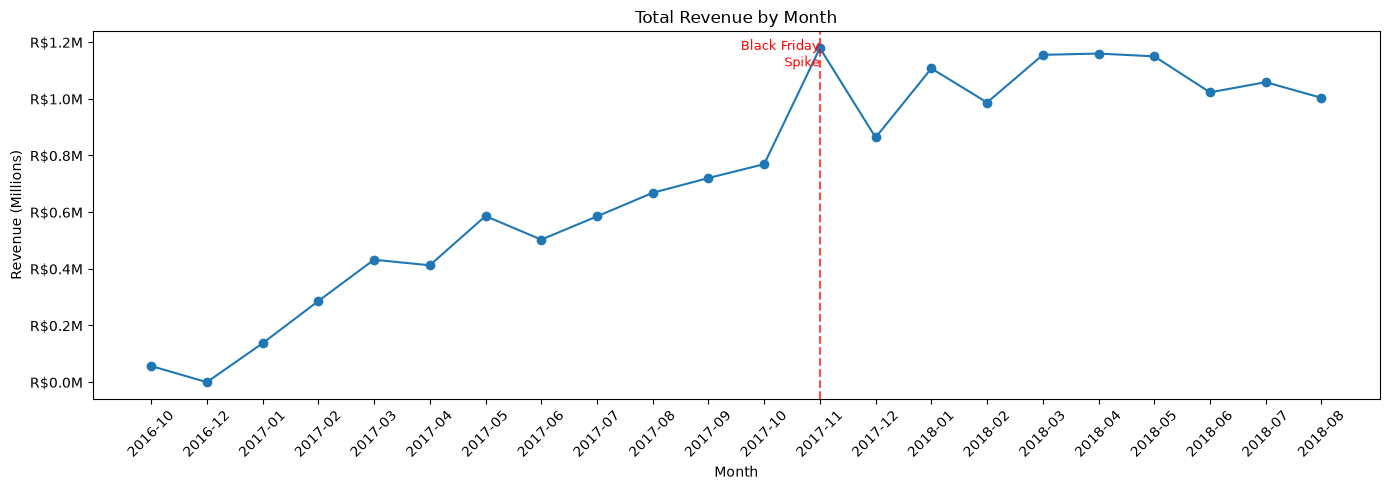

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(revenue_trend['order_month'], revenue_trend['total_revenue'], marker='o')
plt.xticks(rotation=45)
plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue (Millions)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
plt.axvline('2017-11', color='red', linestyle='--', alpha=0.7)
plt.text(
    x='2017-11', 
    y=plt.gca().get_ylim()[1] * 0.9,
    s='Black Friday\nSpike',
    color='red',
    fontsize=9,
    ha='right'
)
plt.tight_layout()
plt.show()

> This chart shows us the total revenue by the month. We can see a clear spike at November 2017, which is where Black Friday is, so we can attribute the spike to that.
>
> We also see a dip around December 2016, which may be due to inacccurate data collection. 

### Review Score Distribution

In [26]:
counts = df_order_reviews['review_score'].value_counts().sort_index()
review_dist = pd.DataFrame({
    'review_score': counts.index,
    'count': counts.values,
    'percentage': counts.values / counts.sum() * 100
})

In [27]:
review_dist

,review_score,count,percentage
0,1,11424,11.513344
1,2,3151,3.175643
2,3,8179,8.242965
3,4,19142,19.291704
4,5,57328,57.776344


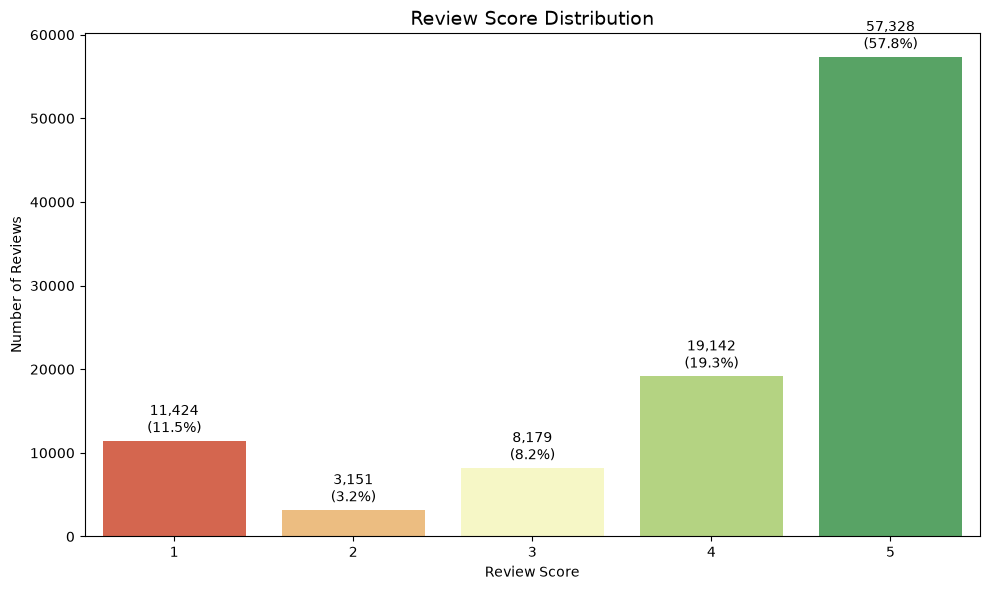

In [28]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=review_dist, x='review_score', y='count', palette='RdYlGn')
for bar, (_, row) in zip(ax.patches, review_dist.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{int(row["count"]):,}\n({row["percentage"]:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title('Review Score Distribution', fontsize=14)
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

> The distribution is heavily skewed toward 5-star ratings (57.8%), with 4 and 5-star reviews combined accounting for 77.1% of all reviews.
>
> However, 1-star reviews represent the third most common rating at 11.5% — more than 2-star and 3-star combined — suggesting a bimodal satisfaction pattern where customers tend to either love or hate their experience, with little middle ground.

### Delivery Performance

In [29]:
df_master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_state', 'item_count', 'price',
       'freight_value', 'review_score', 'review_comment_message',
       'delivery_days', 'delivery_delay', 'total_revenue', 'order_month'],
      dtype='str')

In [30]:
df_delivered = df_master[(df_master['order_status'] == "delivered") & (df_master['delivery_days'].notna())]

In [31]:
df_delivered['delivery_days'].describe(percentiles=[.25, .5, .75, .90, .95, .99])

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
90%         23.000000
95%         29.000000
99%         46.000000
max        209.000000
Name: delivery_days, dtype: float64

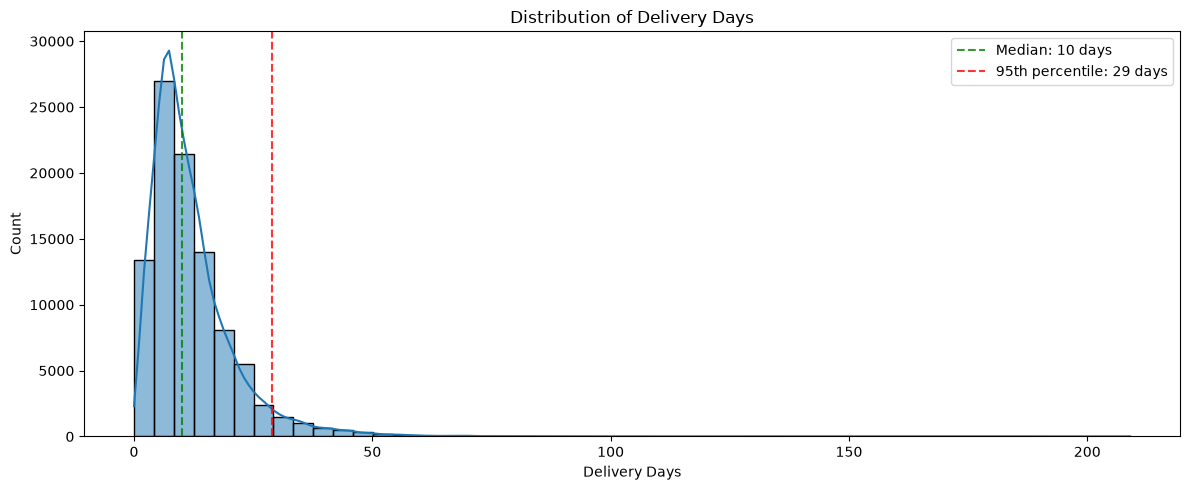

In [32]:
plt.figure(figsize=(12,5))
sns.histplot(data=df_delivered, x='delivery_days', kde=True, bins=50)
plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
percentiles = df_delivered['delivery_days'].quantile([0.25, 0.50, 0.75, 0.95])

plt.axvline(percentiles[0.50], color='green', linestyle='--', alpha=0.8, label=f'Median: {percentiles[0.50]:.0f} days')
plt.axvline(percentiles[0.95], color='red', linestyle='--', alpha=0.8, label=f'95th percentile: {percentiles[0.95]:.0f} days')
plt.legend()
plt.tight_layout()

> We can see in the above histogram that the distribution of delivery days is right skewed, with the majority of delivery day values being between 0 and 25. There are some more between 25 and 50, and a few outliers going all the way up to over 200.
>
> We have also added some markers of the median, 10 days, and 95th percentile, 29 days. We also know that the 99th percentile is 46 days, which means that 99% of all deliveries are delivered in 46 days or less. The deliveries more than 46 days make up less than 1% of all deliveries. 

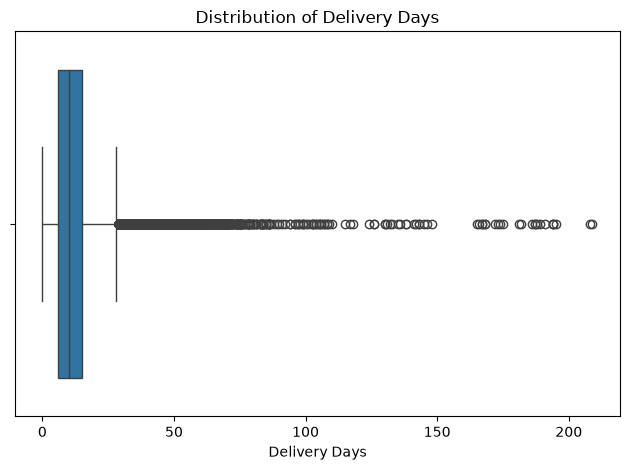

In [33]:
sns.boxplot(data=df_delivered, x='delivery_days')
plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.tight_layout()

> With this boxplot, we can see that the delivery days generally falls between 0 and maybe 28, and quite a few outliers going beyond the upper bound, which means these kinds of delivery length's are not normal. 

## Statistical Testing

In [34]:
from scipy import stats

#### Test 1 — Welch's T-Test: Do Late Deliveries Result in Lower Review Scores?

**Hypothesis:**
- **Null Hypothesis (H₀):** There is no significant difference in average review scores between early and late deliveries
- **Alternative Hypothesis (H₁):** Late deliveries result in significantly lower review scores than early deliveries

**Results:**
| Metric | Value |
|---|---|
| Early Deliveries — Mean Review Score | 4.290 |
| Late Deliveries — Mean Review Score | 2.272 |
| T-Statistic | 100.7448 |
| P-Value | ~0.000000 |
| Statistically Significant (p < 0.05) | True |

**Interpretation:**

Orders that arrived after the estimated delivery date averaged only 2.27 stars, compared to 4.29 stars for orders that arrived early — a difference of over 2 full points on a 5-point scale. The t-statistic of 100.74 is extraordinarily large, and the p-value is effectively zero, meaning the probability of this difference occurring by random chance is negligible.

**Key Takeaway:** Late delivery is a strong driver of poor customer satisfaction. Reducing the 6.8% late delivery rate should be a top priority for improving Olist's overall review scores.



In [35]:
condlist = [
    df_master['delivery_delay'].isna(),
    df_master['delivery_delay'] <= 0,
    df_master['delivery_delay'] > 0
]
choicelist = ['Not Delivered', 'Early', 'Late']

df_master['delivery_status'] = np.select(condlist, choicelist, default='Unknown')

In [36]:
df_master['delivery_status'].value_counts()

delivery_status
Early            89941
Late              6535
Not Delivered     2965
Name: count, dtype: int64

In [37]:
early = df_master[df_master['delivery_status'] == 'Early']['review_score'].dropna()
late = df_master[df_master['delivery_status'] == 'Late']['review_score'].dropna()

In [38]:
t_stat, p_value = stats.ttest_ind(early, late, equal_var=False)

In [39]:
print(f'Early deliveries - Mean review score: {early.mean():.3f}')
print(f'Late deliveries - Mean review score: {late.mean():.3f}')
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.6f}')
print(f'Statistically significant: {p_value < 0.05}')

Early deliveries - Mean review score: 4.290
Late deliveries - Mean review score: 2.272
T-statistic: 100.7448
P-value: 0.000000
Statistically significant: True


#### Test 2 — Chi-Square Test: Is There a Significant Relationship Between Customer State and Review Score?

**Hypothesis:**
- **Null Hypothesis (H₀):** Customer state and review score are independent — where a customer lives has no effect on the review score they give
- **Alternative Hypothesis (H₁):** There is a statistically significant relationship between customer state and review score

**Results:**
| Metric | Value |
|---|---|
| Chi-Square Statistic | 1021.92 |
| Degrees of Freedom | 104 |
| P-Value | ~0.000000 |
| Statistically Significant (p < 0.05) | True |

**Interpretation:**

The chi-square statistic of 1021.92 is extraordinarily large relative to the 104 degrees of freedom — for context, a value above ~130 would already be considered highly significant at p < 0.001. The p-value of effectively zero means the probability of this relationship occurring by random chance is negligible.

The degrees of freedom (104) are calculated as (27 states − 1) × (5 review scores − 1) = 26 × 4, confirming the contingency table was structured correctly.

**Key Takeaway:** Customer state is not independent of review score — geography is a



In [40]:
df_chi = df_master[(df_master['review_score'].notna()) & (df_master['customer_state'].notna())].copy()
df_chi['review_score'] = df_chi['review_score'].round().astype(int)

In [41]:
contingency_table = pd.crosstab(df_chi['customer_state'], df_chi['review_score'])

In [42]:
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

In [43]:
print(f'Chi-square statistic: {chi2:.2f}')
print(f'Degrees of freedom: {dof}')
print(f'P-value: {p_value:.6f}')
print(f'Statistically significant: {p_value < 0.05}')

Chi-square statistic: 1021.92
Degrees of freedom: 104
P-value: 0.000000
Statistically significant: True


## Natural Language Processing

In [44]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from wordcloud import WordCloud

In [45]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\danie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\danie\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\danie\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Inspecting Raw Review Text

In [46]:
df_order_reviews['review_comment_message'].dropna().head(10)

3                 Recebi bem antes do prazo estipulado.
4     Parabéns lojas lannister adorei comprar pela I...
9     aparelho eficiente. no site a marca do aparelh...
12      Mas um pouco ,travando...pelo valor ta Boa.\r\n
15    Vendedor confiável, produto ok e entrega antes...
16    GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...
19                                              Péssimo
22                                         Loja nota 10
24                obrigado pela atençao amim dispensada
27    A compra foi realizada facilmente.\r\nA entreg...
Name: review_comment_message, dtype: str

### Clean the Review Text

In [47]:
portuguese_stopwords = set(stopwords.words('portuguese'))

In [48]:
def clean_text(text):
    if pd.isna(text):
        return ''
    text = text.lower().replace(r'\r\n', ' ')
    tokens = word_tokenize(text, language="portuguese")
    tokens = [t for t in tokens if t.isalpha() and t not in portuguese_stopwords]
    return ' '.join(tokens)
    

In [49]:
clean_text("Recebi bem antes do prazo estipulado.")

'recebi bem antes prazo estipulado'

In [50]:
df_order_reviews['cleaned_message'] = df_order_reviews['review_comment_message'].apply(clean_text)

In [51]:
reviews_5star = df_order_reviews[df_order_reviews['review_score'] == 5]['cleaned_message']
reviews_1star = df_order_reviews[df_order_reviews['review_score'] == 1]['cleaned_message']

In [52]:
reviews_5star.shape

(57328,)

In [53]:
reviews_1star.shape

(11424,)

In [54]:
print(f'5-star empty strings: {(reviews_5star == "").sum()}')
print(f'1-star empty strings: {(reviews_1star == "").sum()}')

5-star empty strings: 36908
1-star empty strings: 2693


Based on the above cells, there are 36908 5 star reviews with empty strings and 2693 1 star reviews with empty strings.

This means that we have 20,420 5 star reviews with text and 8,731 1 star reviews with text to work with. 

In [55]:
reviews_5star_text = reviews_5star[reviews_5star != '']
reviews_1star_text = reviews_1star[reviews_1star != '']

In [56]:
reviews_5star_text.shape

(20420,)

In [57]:
reviews_1star_text.shape

(8731,)

In [58]:
# Combining the text into large strings to do further analysis.
text_5star = ' '.join(reviews_5star_text)
text_1star = ' '.join(reviews_1star_text)

In [59]:
fdist_5star = FreqDist()

In [60]:
token_5star = word_tokenize(text_5star)
for token in token_5star:
    fdist_5star[token.lower()] += 1

In [61]:
fdist_5star.most_common(20)

[('produto', 8067),
 ('prazo', 5656),
 ('antes', 4520),
 ('entrega', 3668),
 ('recomendo', 3269),
 ('chegou', 3208),
 ('bom', 2943),
 ('bem', 2194),
 ('qualidade', 1747),
 ('entregue', 1672),
 ('tudo', 1639),
 ('excelente', 1614),
 ('ótimo', 1524),
 ('super', 1461),
 ('loja', 1165),
 ('rápida', 1143),
 ('recebi', 1046),
 ('gostei', 1044),
 ('compra', 870),
 ('dentro', 839)]

> Some of the most common words in the 5 star reviews are related to the speed of the delivery
>
> prazo - deadline - 5656 times
> 
> antes - before - 4520 times
>
> entrega - delivery - 3668 times
>
> This indicates a strong correlation between positive reviews and delivery time. 

In [62]:
fdist_1star = FreqDist()

In [63]:
token_1star = word_tokenize(text_1star)
for token in token_1star:
    fdist_1star[token.lower()] += 1

In [64]:
fdist_1star.most_common(20)

[('produto', 5065),
 ('recebi', 2777),
 ('comprei', 1551),
 ('ainda', 1177),
 ('veio', 1119),
 ('entregue', 1110),
 ('entrega', 1080),
 ('chegou', 938),
 ('nao', 811),
 ('compra', 756),
 ('prazo', 694),
 ('pedido', 652),
 ('dia', 632),
 ('loja', 632),
 ('agora', 629),
 ('nada', 472),
 ('quero', 455),
 ('apenas', 437),
 ('lannister', 421),
 ('pois', 419)]

> Conversly, some of the most common words in the 1 star reviews are
>
> recebi - I recieved - 2777 times
>
> ainda - still - 1177 times
>
> nao - no/not - 811 times
>
> Which, when put in context, may mean that the delivery did not arrive on time or they are still waiting. 

In [65]:
df_sellers.columns

Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='str')

## Word Clouds

In [66]:
from wordcloud import WordCloud

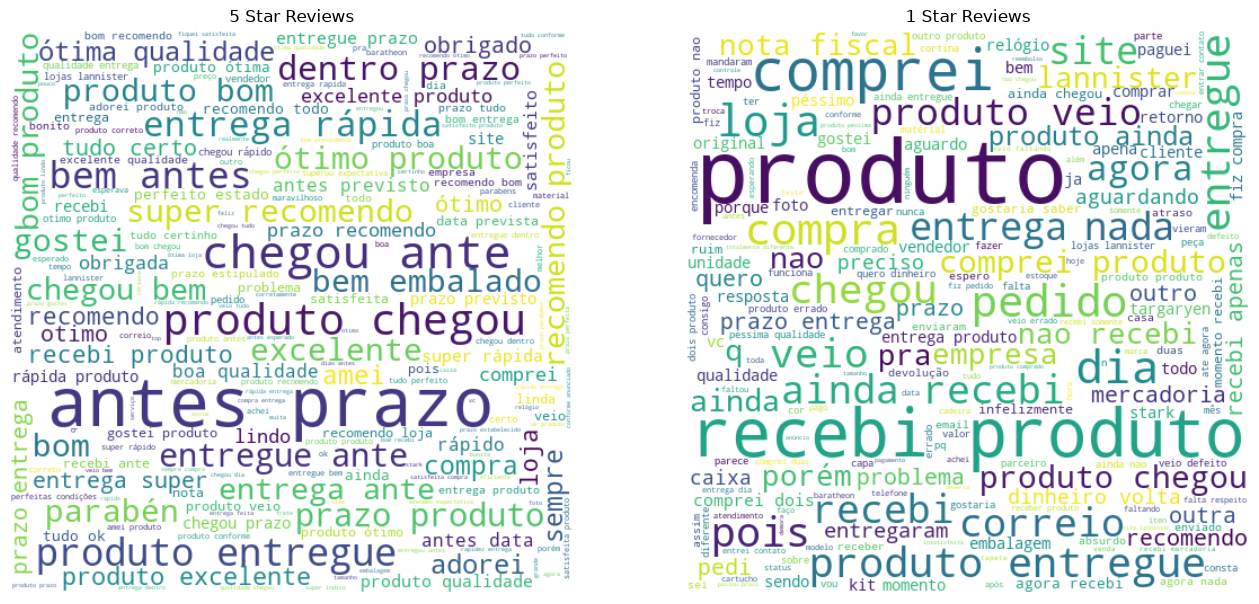

In [67]:
wc5 = WordCloud(width=500, height=500, background_color='white')
wc5.generate(text_5star)
wc1 = WordCloud(width=500, height=500, background_color='white')
wc1.generate(text_1star)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(wc5, interpolation='bilinear')
ax[0].axis('off')
ax[0].set_title("5 Star Reviews")
ax[1].imshow(wc1, interpolation='bilinear')
ax[1].axis('off')
ax[1].set_title("1 Star Reviews")
plt.show()

One of the common words in the 1 star reviews is "Lannister", which is a character on Game of Thrones. This seems to be a proper noun, so it may be referring to a specific product or maybe even a seller. Let's investigate that more. 

### Lannister Investigation

In [68]:
lannister_reviews = df_order_reviews[df_order_reviews['review_comment_message'].str.contains('lannister', case=False, na=False)]

In [69]:
print(f'Total reviews mentioning lannister: {len(lannister_reviews)}')
print(f'\nReview score distribution:')
print(lannister_reviews['review_score'].value_counts().sort_index())
print(f'\nSample comments:')
lannister_reviews['review_comment_message'].head(10).tolist()

Total reviews mentioning lannister: 1208

Review score distribution:
review_score
1    439
2     66
3     75
4     97
5    531
Name: count, dtype: int64

Sample comments:


['Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa',
 'Sempre compro na lannister.Pra mim é a melhor loja on-line',
 'Comprei dois lustres pendentes, com a parceira targaryen e só me enviaram um lustre. Abri reclamação, mas ainda não recebi resposta. Aguardo solução por parte de Lojas lannister.',
 'Não recomendaria esta loja nem pretendo voltar a comprar nela.A mercadoria foi entregue após o prazo e quase 1 mês após a compra. No site das lannister costumam chegar antes do prazo. Estranhei muito',
 'Apesar de ter sido entregue rapidamente, substituíram a caixa METEORO pela caixa BORNE. Quando tentei reclamar nas lannister o sistema estaav fora do ar. A guitarra e acessórios estavam corretos.',
 'Cancelaram a minha compra um dia antes da entrega, liguei para a lannister e os atendentes não sabiam o que estava acontecendo, uma bagunça, agora estou esperando para ver se vai ser cobrado',
 'Última vez que compro pois hoje vai fazer 1 mês 

<Axes: xlabel='review_score', ylabel='count'>

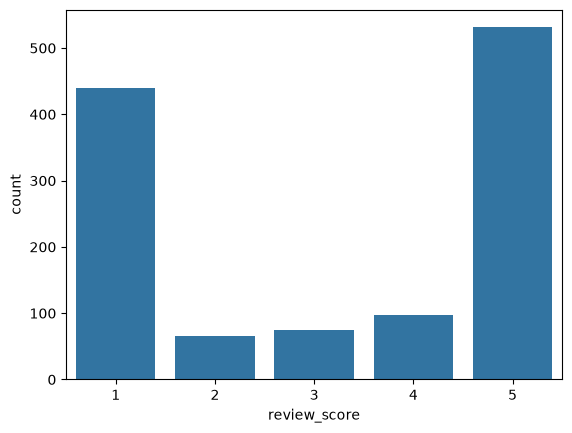

In [70]:
sns.countplot(data=lannister_reviews, x='review_score')

We can see with the above countplot that there are actually quite a bit of negative and positive reviews. This suggests that if they are a seller, they get a mixed set of reviews, but are well known enough to be mentioned many times. 

In [71]:
lannister_reviews[['review_score', 'review_comment_message']].sample(10, random_state=42)

,review_score,review_comment_message
8927,1,O pedido veio errado. Está a maior burocracia ...
62481,5,Sempre gostei das lannister
26163,1,Fui enganado. ficou faltando um produto e me e...
9502,4,Apesar de ter sido entregue no prazo levou dez...
52415,2,Gostaria de sabe o que aconteceu com meu produ...
36745,5,Nota 10 para lannister e targaryen!!!!
20240,5,O produto chegou antes do que imaginei. Até me...
3664,1,Estou esperando até agora a entrega do produto...
62711,1,Há tempo estou entrando em contato com a lanni...
89266,1,Estou aguardando o produto até agora!\r\nEsper...


**Finding:** "Lannister" (and related brand "Targaryen") appears to be a Game of Thrones themed seller 
group operating on Olist, with 1,208 total review mentions. Their review distribution is notably 
bimodal — 531 five-star vs 439 one-star — with positive reviews praising fast delivery and product 
quality, while negative reviews consistently cite non-delivery, missing items, and poor seller 
communication. This seller-specific pattern emerged organically from word frequency analysis and 
represents a concrete example of how NLP can surface actionable seller quality insights at scale.

## Predicting Late Deliveries

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

In [73]:
df_master.shape

(99441, 20)

In [74]:
df_master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_state', 'item_count', 'price',
       'freight_value', 'review_score', 'review_comment_message',
       'delivery_days', 'delivery_delay', 'total_revenue', 'order_month',
       'delivery_status'],
      dtype='str')

In [75]:
df_seller_state = df_order_items.merge(df_sellers, on='seller_id').groupby('order_id').agg({'seller_state': lambda x: x.mode()[0]}).reset_index()

In [76]:
df_seller_state.head()

,order_id,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,SP
1,00018f77f2f0320c557190d7a144bdd3,SP
2,000229ec398224ef6ca0657da4fc703e,MG
3,00024acbcdf0a6daa1e931b038114c75,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,PR


In [77]:
df_master = df_master.merge(df_seller_state, on='order_id', how='left')

In [78]:
df_master['seller_state'].isna().sum()

np.int64(775)

In [79]:
df_model = df_master[df_master['delivery_status'].isin(['Early', 'Late'])].copy()
df_model = df_model.dropna(subset=['customer_state', 'seller_state', 'item_count', 'price', 'freight_value', 'order_month'])

In [80]:
print(df_model.shape)
print(df_model['delivery_status'].value_counts())

(96476, 21)
delivery_status
Early    89941
Late      6535
Name: count, dtype: int64


In [81]:
df_model.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,...,price,freight_value,review_score,review_comment_message,delivery_days,delivery_delay,total_revenue,order_month,delivery_status,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,...,29.99,8.72,4.0,"Não testei o produto ainda, mas ele veio corre...",8.0,-8.0,38.71,2017-10,Early,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,...,118.70,22.76,4.0,Muito bom o produto.,13.0,-6.0,141.46,2018-07,Early,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,...,159.90,19.22,5.0,NaN,9.0,-18.0,179.12,2018-08,Early,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,RN,...,45.00,27.20,5.0,O produto foi exatamente o que eu esperava e e...,13.0,-13.0,72.20,2017-11,Early,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,SP,...,19.90,8.72,5.0,NaN,2.0,-10.0,28.62,2018-02,Early,SP


In [82]:
df_model['is_late'] = np.where(df_model['delivery_status'] == 'Early', 0, 1)

In [83]:
features = ['customer_state', 'seller_state', 'item_count', 'price', 'freight_value', 'order_month']

In [84]:
X = df_model[features]
y = df_model['is_late']

In [85]:
le_cs = LabelEncoder()
le_ss = LabelEncoder()
le_om = LabelEncoder()

In [86]:
X['customer_state'] =  le_cs.fit_transform(X['customer_state'])
X['seller_state'] =  le_ss.fit_transform(X['seller_state'])
X['order_month'] =  le_om.fit_transform(X['order_month'])

In [87]:
X.head()

,customer_state,seller_state,item_count,price,freight_value,order_month
0,25,21,1.0,29.99,8.72,12
1,4,21,1.0,118.70,22.76,21
2,8,21,1.0,159.90,19.22,22
3,19,7,1.0,45.00,27.20,13
4,25,21,1.0,19.90,8.72,16


In [88]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: is_late, dtype: int64

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [90]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

In [91]:
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [92]:
rf.score(X_test, y_test)

0.8834991708126037

In [93]:
preds = rf.predict(X_test)

In [94]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94     17989
           1       0.20      0.24      0.22      1307

    accuracy                           0.88     19296
   macro avg       0.57      0.59      0.58     19296
weighted avg       0.89      0.88      0.89     19296



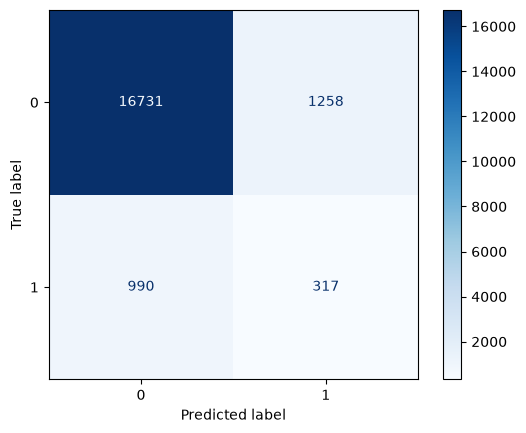

In [95]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap='Blues')

In [96]:
feat_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(feat_importance)

          feature  importance
3           price    0.341409
4   freight_value    0.288263
5     order_month    0.201691
0  customer_state    0.109640
1    seller_state    0.046040
2      item_count    0.012958


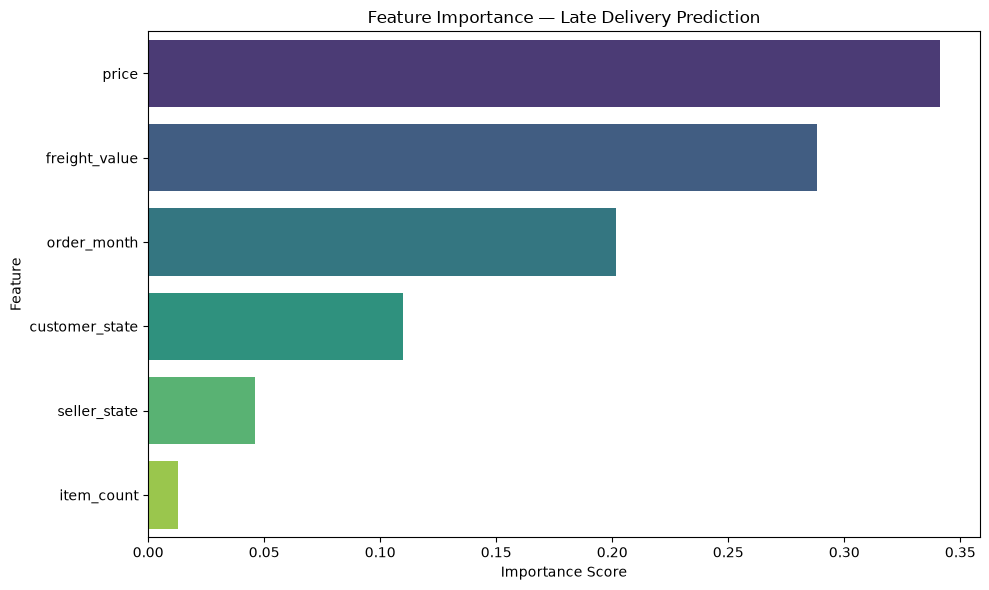

In [97]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance — Late Delivery Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Predictive Model — Late Delivery Prediction

#### Objective
Build a binary classifier to predict whether an order will be delivered late (after the estimated 
delivery date) using only information available at the time of purchase. This has real business 
value — proactively identifying at-risk orders allows Olist to notify customers early, offer 
goodwill gestures, or escalate to logistics partners before satisfaction is impacted.

#### Approach
**Features used:** `price`, `freight_value`, `order_month`, `customer_state`, `seller_state`, 
`item_count`

**Preprocessing:**
- Categorical features (`customer_state`, `seller_state`, `order_month`) encoded using 
`LabelEncoder` — appropriate for tree-based models which are scale-invariant and not misled 
by ordinal encoding
- No normalization applied — Random Forests do not require feature scaling

**Class imbalance handling:**
The dataset is heavily imbalanced — 89,941 Early deliveries vs 6,535 Late (93% vs 7%). 
Two strategies were applied:
- `stratify=y` in train/test split to preserve class ratios in both sets
- `class_weight='balanced'` in the Random Forest to penalize misclassification of the 
minority (Late) class more heavily during training

#### Results

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| Early (0) | 0.94 | 0.93 | 0.94 | 17,989 |
| Late (1) | 0.20 | 0.24 | 0.22 | 1,307 |
| **Overall Accuracy** | | | **0.88** | **19,296** |

#### Feature Importance

| Feature | Importance |
|---|---|
| price | 34.1% |
| freight_value | 28.8% |
| order_month | 20.2% |
| customer_state | 11.0% |
| seller_state | 4.6% |
| item_count | 1.3% |

#### Interpretation
The model predicts Early deliveries well (F1: 0.94) but struggles with Late deliveries 
(F1: 0.22). While `class_weight='balanced'` forces the model to pay more attention to Late 
cases, the features available at purchase time simply don't contain enough signal to reliably 
identify which orders will be late.

`price` and `freight_value` together account for 63% of predictive power — likely acting as 
proxies for shipment distance and order complexity. `order_month` (20%) captures seasonality 
effects, confirming that peak periods like November (Black Friday) strain logistics capacity. 
`customer_state` contributes less than expected (11%) because its geographic signal is already 
partially captured by `freight_value`.

#### Key Takeaway
Late delivery is genuinely difficult to predict from order-level features alone — the model's 
poor recall on the Late class (0.24) reflects this fundamental limitation rather than a 
modeling error. This is itself a meaningful business finding: preventing late deliveries 
requires operational improvements (logistics infrastructure, carrier partnerships, warehouse 
distribution) rather than predictive flagging of individual orders.

#### Limitations & Future Improvements
- **Additional features** that could improve Late prediction: historical seller on-time rate, 
carrier performance metrics, real-time weather/logistics disruption data, distance between 
seller and customer zip codes
- **Alternative models** worth trying: XGBoost or LightGBM (often outperform Random Forest 
on imbalanced datasets), or a cost-sensitive learning approach
- **Threshold tuning** — lowering the classification threshold from 0.5 could improve Late 
recall at the cost of more false positives, which may be acceptable in a business context 
where proactive notification is cheap